Use Case 3 : Loan Amount Prediction

In [2]:
#Importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
df = pd.read_csv(
    "../dataset/hdfc_loan_dataset_full_enriched_cleaned.csv"
)

In [4]:
df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,0,0,31,1,0,2,0,1,56976,0,...,11.747,2,2,0,5,857743,6.940000e+11,9068671773,31,8
1,1,0,31,1,0,0,0,3,1856,0,...,40.381,0,2,5,15,863836,6.330000e+11,9990772625,31,2
2,2,0,1,0,1,0,0,1,64553,0,...,3.082,2,2,4,19,834796,1.660000e+11,9195085016,1,12
3,3,0,4,1,0,0,0,1,88450,0,...,0.621,0,2,1,27,438590,5.528183e+10,9179335548,4,11
4,4,0,11,1,1,3,0,2,9539,0,...,1.736,1,4,9,12,495224,1.560000e+11,9795137116,11,14


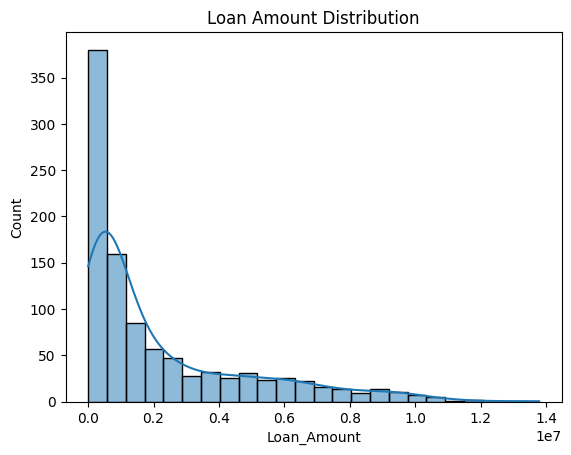

In [5]:
sns.histplot(
    df['Loan_Amount'],
    kde=True
)

plt.title(
    "Loan Amount Distribution"
)

plt.show()

In [6]:
features = [

    'Applicant_Income',
    'Annual_Household_Income',
    'Asset_Value',
    'Existing_EMIs',
    'Employment_Length_Years',
    'CIBIL_Score',
    'Monthly_Expense',
    'Debt_to_Income_Ratio',
    'Occupation',
    'Property_Area'
]

In [7]:
num_cols = [
    'Applicant_Income',
    'Annual_Household_Income',
    'Asset_Value',
    'Existing_EMIs',
    'Employment_Length_Years',
    'CIBIL_Score',
    'Monthly_Expense',
    'Debt_to_Income_Ratio'
]

In [8]:
for col in num_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )

In [9]:
cat_cols = [
    'Occupation',
    'Property_Area'
]

In [10]:
for col in cat_cols:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [11]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(
        df[col]
    )

In [12]:
#Define X and Y
X = df[features]
y = df['Loan_Amount']

In [13]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train
)
X_test_scaled = scaler.transform(
    X_test
)

In [15]:
#Training Model 1 - Linear Regression
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
#Predict using Linear Regression
lr_pred = lr.predict(
    X_test_scaled
)

In [17]:
#Evaluation metrics of Linear Regression
mae = mean_absolute_error(
    y_test,
    lr_pred
)
mse = mean_squared_error(
    y_test,
    lr_pred
)
rmse = np.sqrt(mse)
r2 = r2_score(
    y_test,
    lr_pred
)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2007567.9113371093
MSE: 6263736638646.301
RMSE: 2502745.819823959
R2: -0.03685269925375123


In [18]:
#Creating Evaluate function
def evaluate_regression(
    y_true,
    y_pred,
    model_name
):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    mse = mean_squared_error(
        y_true,
        y_pred
    )
    rmse = np.sqrt(mse)
    r2 = r2_score(
        y_true,
        y_pred
    )
    print(f"\n{model_name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)

In [19]:
evaluate_regression(
    y_test,
    lr_pred,
    "Linear Regression"
)


Linear Regression
MAE: 2007567.9113371093
MSE: 6263736638646.301
RMSE: 2502745.819823959
R2: -0.03685269925375123


In [20]:
#Training Model 2 - Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
#Predict using Random Forest Regressor
rf_pred = rf.predict(
    X_test
)

In [22]:
#Evaluate Random Forest
evaluate_regression(
    y_test,
    rf_pred,
    "Random Forest Regressor"
)


Random Forest Regressor
MAE: 2224606.0316999997
MSE: 7389765983953.841
RMSE: 2718412.401375818
R2: -0.22324728023239504


In [23]:
#Training Model 3 - Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(
    X_train,
    y_train
)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [24]:
#Predict using Gradient Boosting
gbr_pred = gbr.predict(
    X_test
)

In [25]:
#Evaluate Gradient Boosting
evaluate_regression(
    y_test,
    gbr_pred,
    "Gradient Boosting Regressor"
)


Gradient Boosting Regressor
MAE: 2200397.4595068265
MSE: 7606223495395.143
RMSE: 2757938.2689601923
R2: -0.259078057922973


In [26]:
#Calculate metrics for all models
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_mse = mean_squared_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(gbr_mse)
gbr_r2 = r2_score(y_test, gbr_pred)

#Create a results table for model performance comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [lr_rmse, rf_rmse, gbr_rmse],
    "R2": [lr_r2, rf_r2, gbr_r2]
})

results

,Model,RMSE,R2
0,Linear Regression,2.502746e+06,-0.036853
1,Random Forest,2.718412e+06,-0.223247
2,Gradient Boosting,2.757938e+06,-0.259078


In [27]:
#Hyperparameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

In [28]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [29]:
grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [30]:
print(
    grid.best_params_
)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [31]:
#Extracting best Model
best_rf = grid.best_estimator_

In [32]:
best_pred = best_rf.predict(
    X_test
)

In [33]:
#Evaluate tuned Model
evaluate_regression(
    y_test,
    best_pred,
    "Tuned Random Forest"
)


Tuned Random Forest
MAE: 2016268.8247206921
MSE: 6405504638914.228
RMSE: 2530909.8440905055
R2: -0.06031992692080923


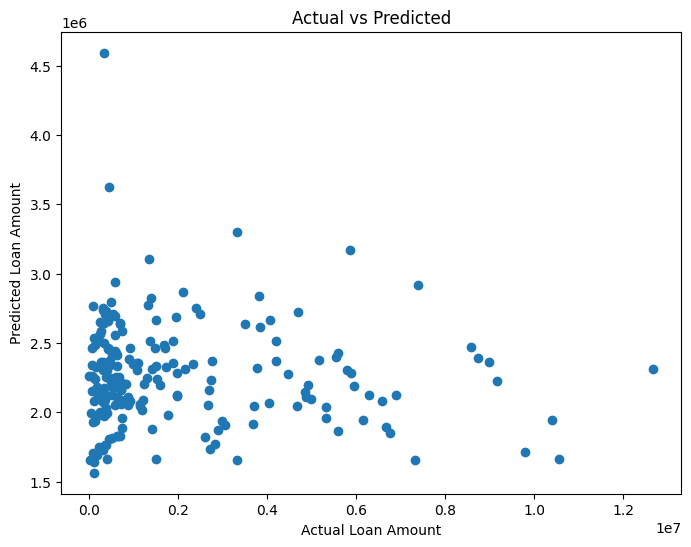

In [34]:
#Actual vs Predicted visualization
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    best_pred
)
plt.xlabel(
    "Actual Loan Amount"
)
plt.ylabel(
    "Predicted Loan Amount"
)
plt.title(
    "Actual vs Predicted"
)
plt.show()

In [38]:
plt.savefig(
    "../visuals/actual_vs_predicted.png"
)

<Figure size 640x480 with 0 Axes>

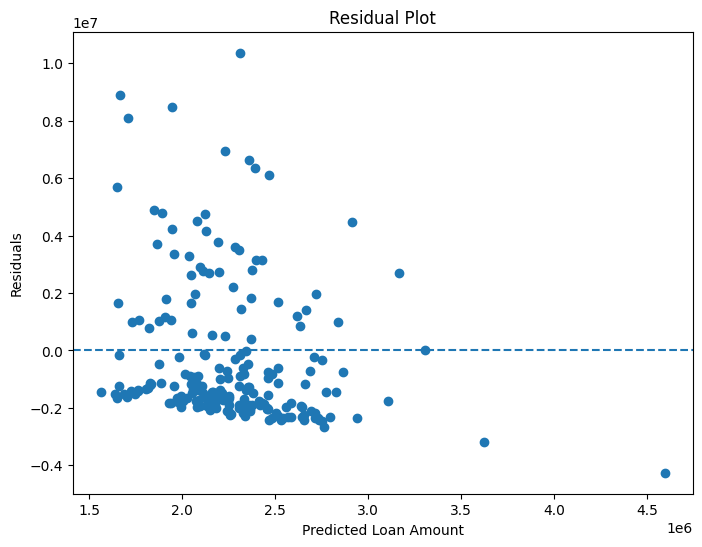

In [36]:
#Residual Analysis plot
residuals = y_test - best_pred
plt.figure(figsize=(8,6))

plt.scatter(
    best_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel(
    "Predicted Loan Amount"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Residual Plot"
)

plt.show()

In [37]:
plt.savefig(
    "../visuals/loan_amount_prediction_residual_plot.png"
)

<Figure size 640x480 with 0 Axes>

In [39]:
#Feature importance Analysis
importance = best_rf.feature_importances_
feature_importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':importance
})

In [41]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance

,Feature,Importance
2,Asset_Value,0.132797
6,Monthly_Expense,0.119126
5,CIBIL_Score,0.115807
1,Annual_Household_Income,0.112455
4,Employment_Length_Years,0.109685
3,Existing_EMIs,0.105163
0,Applicant_Income,0.103634
7,Debt_to_Income_Ratio,0.080007
8,Occupation,0.066425
9,Property_Area,0.054901


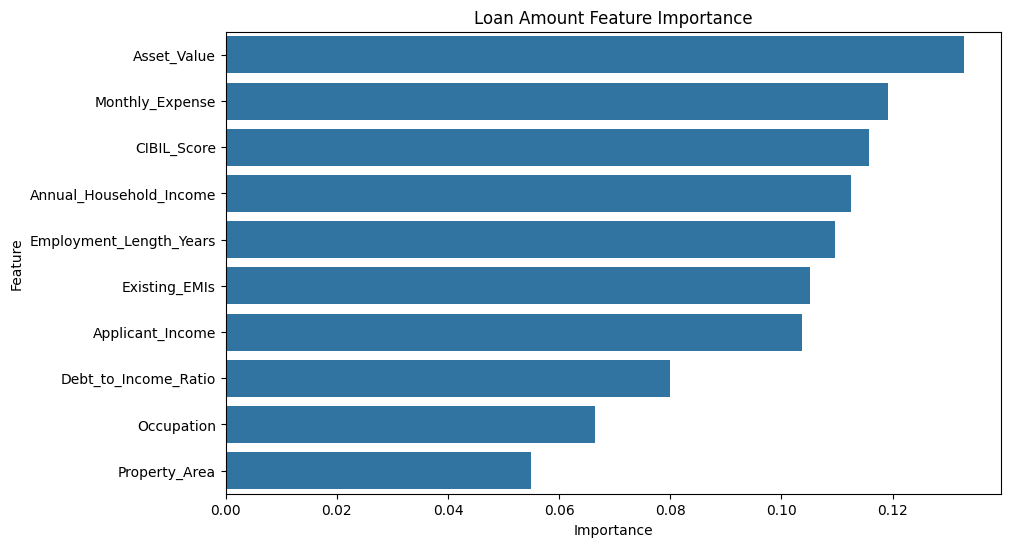

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=feature_importance,

    x='Importance',

    y='Feature'
)

plt.title(
    "Loan Amount Feature Importance"
)

plt.show()

In [43]:
plt.savefig(
    "../visuals/loan_amount_feature_importance.png"
)

<Figure size 640x480 with 0 Axes>

In [44]:
#Save the best model using joblib
joblib.dump(

    best_rf,

    "../models/loan_amount_model.pkl"
)

['../models/loan_amount_model.pkl']

In [46]:
#Save the scaler for future use in prediction
joblib.dump(

    scaler,

    "../models/loan_amount_scaler.pkl"
)

['../models/loan_amount_scaler.pkl']

In [48]:
#Load the saved model for verification
loaded_model = joblib.load(
    "../models/loan_amount_model.pkl"
)

In [49]:
loaded_model.predict(
    X_test.head()
)

array([2248415.31133636, 2566995.84762151, 2303582.71791696,
       2246880.6989658 , 4593927.53350114])

In [51]:
#Create a model comparison table
best_mae = mean_absolute_error(y_test, best_pred)
best_mse = mean_squared_error(y_test, best_pred)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_pred)

final_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'Tuned Random Forest'
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        gbr_mae,
        best_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        gbr_rmse,
        best_rmse
    ],
    'R2': [
        lr_r2,
        rf_r2,
        gbr_r2,
        best_r2
    ]
})

final_results

,Model,MAE,RMSE,R2
0,Linear Regression,2.007568e+06,2.502746e+06,-0.036853
1,Random Forest,2.224606e+06,2.718412e+06,-0.223247
2,Gradient Boosting,2.200397e+06,2.757938e+06,-0.259078
3,Tuned Random Forest,2.016269e+06,2.530910e+06,-0.060320
